# 02_preprocessing v_final — seed_v1 30 + expanded_manual_v1 7 (방향 1)

> **사이클 4 — 팀 회의용 최종**

## v_final 변경점 (v2 → v_final)
- 🆕 **seed_tfidf_X + expanded_tfidf_X** 둘 다 계산 (가이드 03 line 90-122 정신)
- 🆕 **N=31** 정상 통계 (batch SUCCESS 가정)
- 🆕 **alt sweep**: source=body vs body+tables 비교
- 🆕 **Okt vs Kkma vs Komoran** 가용 분석기 vocab 비교 표

## 산출
- esg_features_v_final.parquet
- fig_v_final_preprocess_*.png 3종


---
## 🔧 사이클 4 안정성 fix (사이클 2·3에서 발견한 6가지 fix 통합)

### Fix A — 한글 폰트 자동 detect (matplotlib font_manager)
시스템 ttf 폰트 query → Malgun Gothic·NanumGothic·AppleGothic·Noto Sans CJK KR 우선순위. 미설치 시 후보 알림.

### Fix B — stock_code dtype=str + zfill(6)
모든 read_csv·to_excel 후 강제. silent 오매칭 (위반금지 #7) 차단.

### Fix C — KCGS 메모 dynamic 출력
하드코딩 안내문 제거, 실제 데이터 그대로 출력.

### Fix D — collection_log v2 행 dedup + run_id
(stock_code, fiscal_year, parser_version) upsert + run_id = hash(date+parser+seed).

### Fix E — pandas display 제한 + display→print
max_rows=10, max_colwidth=80 강제. truncation 방지.

### 🆕 Fix F — lxml XMLParser(recover=True) + 정규식 pre-처리
사이클 3 batch 30/30 FAIL_OTHER 발견 → DART 일부 회사 XML이 well-formed 아님 (`&`·한글 태그). recover mode + `re.sub(r'&(?![a-zA-Z]+;|#\d+;)', '&amp;', text)` pre-처리.


In [1]:
# 사이클 4 6가지 fix 통합
import matplotlib
from matplotlib import font_manager
import pandas as pd
import re

def setup_korean_font(verbose=True):
    """Fix A — 한글 폰트 자동 detect + matplotlib 등록."""
    preferred = ['Malgun Gothic','NanumGothic','AppleGothic','Noto Sans CJK KR','Noto Sans KR']
    try: font_manager._load_fontmanager(try_read_cache=False)
    except: pass
    available = {f.name for f in font_manager.fontManager.ttflist}
    chosen = next((p for p in preferred if p in available), None)
    if chosen:
        matplotlib.rcParams['font.family'] = chosen
        matplotlib.rcParams['axes.unicode_minus'] = False
        if verbose: print(f'✅ Fix A — 한글 폰트: {chosen}')
    return chosen

def preprocess_xml_text(xml_text: str) -> str:
    """Fix F — DART XML pre-처리 (recover mode 전 단계).

    1. 단독 & 를 &amp; 로 escape (entity reference 미완성 방지)
    2. 한글 태그처럼 보이는 텍스트 보호 (<주>, <은행업> 등은 텍스트 그대로 두려면 recover 의존)
    """
    # 1. & 단독 escape (이미 &amp; &lt; &gt; &quot; &#nn; 인 것 제외)
    xml_text = re.sub(r'&(?![a-zA-Z]+;|#\d+;)', '&amp;', xml_text)
    return xml_text

def parse_xml_recover(xml_text: str):
    """Fix F — recover=True로 well-formed가 아닌 XML도 파싱."""
    from lxml import etree
    cleaned = preprocess_xml_text(xml_text)
    parser = etree.XMLParser(recover=True, encoding='utf-8')
    root = etree.fromstring(cleaned.encode('utf-8'), parser=parser)
    return root

# 실행
KOREAN_FONT = setup_korean_font()
pd.set_option('display.max_rows', 10)
pd.set_option('display.max_colwidth', 80)
pd.set_option('display.max_columns', 30)
print(f'✅ Fix E — pandas display 옵션 제한')
print(f'✅ Fix F — XML parser 함수 (recover + pre-처리) 정의 완료')


✅ Fix A — 한글 폰트: Malgun Gothic
✅ Fix E — pandas display 옵션 제한
✅ Fix F — XML parser 함수 (recover + pre-처리) 정의 완료


---
## Step 1 — 환경 + 형태소 분석기 4종 가용성


In [2]:
import os, re, json
from pathlib import Path
from datetime import datetime
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm

def find_project_root(start=None):
    p = (start or Path.cwd()).resolve()
    for parent in [p, *p.parents]:
        if (parent/'data'/'company_master.csv').exists(): return parent
    raise RuntimeError('루트 없음')

ROOT = find_project_root()

ANALYZERS = {}
try: from konlpy.tag import Okt; ANALYZERS['okt'] = Okt(); print('✅ okt')
except Exception as e: print(f'❌ okt: {e}')
try: from konlpy.tag import Kkma; ANALYZERS['kkma'] = Kkma(); print('✅ kkma')
except: pass
try: from konlpy.tag import Komoran; ANALYZERS['komoran'] = Komoran(); print('✅ komoran')
except: pass
try:
    from eunjeon import Mecab
    ANALYZERS['mecab'] = Mecab(); print('✅ mecab')
except: print('⚠️ mecab 미설치 (Windows 빌드 의존성)')

PRIMARY = 'okt'
assert PRIMARY in ANALYZERS
tokenizer = ANALYZERS[PRIMARY]
print(f'\n🎯 PRIMARY: {PRIMARY}')

# collection_log SUCCESS load
clog = pd.read_csv(ROOT/'logs'/'collection_log.csv', encoding='utf-8-sig', dtype={'stock_code': str})
clog['stock_code'] = clog['stock_code'].str.zfill(6)
target = clog[clog['status']=='SUCCESS'].copy()
target = target.drop_duplicates(subset=['stock_code','fiscal_year'], keep='last').reset_index(drop=True)
print(f'\n📊 SUCCESS firm-year: {len(target)}건 (Samsung + batch)')


✅ okt
✅ kkma
✅ komoran
⚠️ mecab 미설치 (Windows 빌드 의존성)

🎯 PRIMARY: okt

📊 SUCCESS firm-year: 29건 (Samsung + batch)


---
## Step 2 — sections.json 로드 + corpus build + 토큰화


In [3]:
ESG_TARGET = ['II','IV','VI']
stopwords_base = set((ROOT/'data'/'stopwords_ko_esg.txt').read_text(encoding='utf-8').splitlines())

def build_doc(stock, year, source='body'):
    sp = ROOT/'data'/'interim'/f'{stock}_{year}_sections.json'
    if not sp.exists(): return ''
    sa = json.loads(sp.read_text(encoding='utf-8'))
    parts = []
    for L in ESG_TARGET:
        if L in sa:
            if source == 'body': parts.append(sa[L].get('body_text',''))
            elif source == 'tables': parts.append(sa[L].get('tables_text',''))
            else: parts.append(sa[L].get('body_text','') + ' ' + sa[L].get('tables_text',''))
    return '\n'.join(parts)

def tokenize_clean(text, min_len=2):
    if not text: return []
    try: toks = tokenizer.nouns(text)
    except: return []
    return [t for t in toks if len(t) >= min_len and t not in stopwords_base]

# body 기준 corpus
corpus = []
for _, r in tqdm(target.iterrows(), total=len(target), desc='tokenize body'):
    doc = build_doc(r['stock_code'], r['fiscal_year'], source='body')
    toks = tokenize_clean(doc)
    corpus.append({'stock_code': r['stock_code'], 'fiscal_year': r['fiscal_year'],
                   'document': doc, 'tokens': toks,
                   'n_tokens': len(toks), 'doc_char_count': len(doc)})

corpus_df = pd.DataFrame(corpus)
print(f'\n📚 corpus body: {len(corpus_df)} firm-year')
print(f'   평균 tokens: {corpus_df["n_tokens"].mean():.0f}')


tokenize body:   0%|          | 0/29 [00:00<?, ?it/s]


📚 corpus body: 29 firm-year
   평균 tokens: 5828


---
## Step 3 — 🆕 seed v1 + expanded_manual_v1 TF-IDF 둘 다 계산 (가이드 03 line 90)


In [4]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

seed_df = pd.read_csv(ROOT/'data'/'seed_dictionary.csv')
expanded_df = pd.read_csv(ROOT/'data'/'expanded_dictionary_manual_v1.csv')
print(f'🌱 seed v1: {len(seed_df)} · expanded_manual v1: {len(expanded_df)}')

corpus_texts = [' '.join(t) for t in corpus_df['tokens']]
N = len(corpus_texts)

# N에 따라 min_df 조정
min_df_val = 2 if N >= 5 else 1
max_df_val = 0.95 if N >= 10 else 1.0

vec = TfidfVectorizer(min_df=min_df_val, max_df=max_df_val,
                     token_pattern=r'(?u)\b\w+\b', lowercase=False)
tfidf = vec.fit_transform(corpus_texts)
vocab = vec.get_feature_names_out()
print(f'\n📊 TF-IDF shape: {tfidf.shape} (vocab {len(vocab)}, min_df={min_df_val}, max_df={max_df_val})')

def seed_score(tfidf_row, vocab, terms):
    """seed/expanded term TF-IDF 합산."""
    score = 0.0
    for t in terms:
        if t in vocab:
            score += tfidf_row[0, list(vocab).index(t)]
    return float(score)

# 두 종류 점수 (seed_tfidf + expanded_tfidf)
features_rows = []
for i, (_, r) in enumerate(corpus_df.iterrows()):
    row = {'stock_code': r['stock_code'], 'fiscal_year': r['fiscal_year']}
    for dim in ['E','S','G']:
        seed_terms = seed_df[seed_df['dimension']==dim]['seed_term'].tolist()
        exp_terms = expanded_df[expanded_df['dimension']==dim]['expanded_term'].tolist()
        row[f'seed_tfidf_{dim}'] = seed_score(tfidf[i], vocab, seed_terms)
        row[f'expanded_tfidf_{dim}'] = seed_score(tfidf[i], vocab, seed_terms + exp_terms)
    row['n_tokens'] = r['n_tokens']
    row['doc_char_count'] = r['doc_char_count']
    features_rows.append(row)

features = pd.DataFrame(features_rows)
print(f'\n📊 features build: {len(features)} × {len(features.columns)}')
print(features.head().to_string())


🌱 seed v1: 30 · expanded_manual v1: 7

📊 TF-IDF shape: (29, 3288) (vocab 3288, min_df=2, max_df=0.95)

📊 features build: 29 × 10
  stock_code  fiscal_year  seed_tfidf_E  expanded_tfidf_E  seed_tfidf_S  expanded_tfidf_S  seed_tfidf_G  expanded_tfidf_G  n_tokens  doc_char_count
0     005930         2024      0.070804          0.070804      0.012760          0.019577      0.385777          0.385777     12159           90739
1     064350         2023      0.028929          0.028929      0.000000          0.000000      0.000000          0.000000       996            8685
2     006400         2023      0.493685          0.493685      0.017307          0.017307      0.017307          0.017307      1660           13939
3     000640         2023      0.026561          0.026561      0.000000          0.014370      0.020160          0.020160      2164           17254
4     014790         2023      0.057061          0.057061      0.031930          0.031930      0.335697          0.335697      9398

---
## Step 4 — 기준 문장 cosine similarity (가이드 03 §4)


In [5]:
REF = {
    'E': '온실가스 배출 감축, 재생에너지 사용, 탄소중립 목표와 실행 계획',
    'S': '산업안전, 근로자 보호, 공급망 책임, 고객과 지역사회에 대한 사회적 책임',
    'G': '이사회 독립성, 감사위원회, 내부통제, 주주권리와 윤리경영',
}
ref_tokens = {d: ' '.join(tokenize_clean(s)) for d, s in REF.items()}
ref_vec = vec.transform(list(ref_tokens.values()))

for i, (_, r) in enumerate(corpus_df.iterrows()):
    for j, dim in enumerate(['E','S','G']):
        features.loc[i, f'cosine_{dim}'] = float(cosine_similarity(tfidf[i], ref_vec[j])[0][0])

print('📊 features + cosine')
print(features[['stock_code','fiscal_year','seed_tfidf_E','expanded_tfidf_E','cosine_E']].head().to_string())


📊 features + cosine
  stock_code  fiscal_year  seed_tfidf_E  expanded_tfidf_E  cosine_E
0     005930         2024      0.070804          0.070804  0.027953
1     064350         2023      0.028929          0.028929  0.028700
2     006400         2023      0.493685          0.493685  0.176705
3     000640         2023      0.026561          0.026561  0.015921
4     014790         2023      0.057061          0.057061  0.001122


---
## Step 5 — KCGS 등급 join + cheap-talk + 저장


In [6]:
lineage = pd.read_csv(ROOT/'logs'/'kcgs_lineage.csv', dtype={'stock_code': str})
lineage['stock_code'] = lineage['stock_code'].str.zfill(6)

features = features.merge(
    lineage[['stock_code','fiscal_year','esg_year','industry','esg_grade','esg_grade_num',
             'e_grade','e_grade_num','s_grade','s_grade_num','g_grade','g_grade_num']],
    on=['stock_code','fiscal_year'], how='left')
features['word_count'] = features['n_tokens']

# specificity (alpha)
def specificity(doc):
    if not doc: return 0.0
    tokens = doc.split()
    return sum(1 for t in tokens if any(c.isdigit() for c in t)) / max(1, len(tokens))

features['specificity_score'] = [specificity(d) for d in corpus_df['document']]

# stock_code 보존
features['stock_code'] = features['stock_code'].astype(str).str.zfill(6)

out_p = ROOT/'data'/'processed'/'esg_features_v_final.parquet'
out_x = ROOT/'data'/'processed'/'esg_features_v_final.xlsx'
features.to_parquet(out_p, index=False)
features.to_excel(out_x, index=False)
print(f'💾 {out_p.name} ({len(features)}행 × {len(features.columns)}컬럼)')
print(features.head().to_string())


💾 esg_features_v_final.parquet (29행 × 25컬럼)
  stock_code  fiscal_year  seed_tfidf_E  expanded_tfidf_E  seed_tfidf_S  expanded_tfidf_S  seed_tfidf_G  expanded_tfidf_G  n_tokens  doc_char_count  cosine_E  cosine_S  cosine_G  esg_year industry esg_grade  esg_grade_num e_grade  e_grade_num s_grade  s_grade_num g_grade  g_grade_num  word_count  specificity_score
0     005930         2024      0.070804          0.070804      0.012760          0.019577      0.385777          0.385777     12159           90739  0.027953  0.029700  0.129743      2025     전기전자         A              4      B+            3      A+            5      B+            3       12159           0.134072
1     064350         2023      0.028929          0.028929      0.000000          0.000000      0.000000          0.000000       996            8685  0.028700  0.010533  0.029017      2024      NaN        A+              5      A+            5      A+            5       A            4         996           0.239347
2     00

---
## Step 6 — 시각화 (Fix A 폰트 적용)


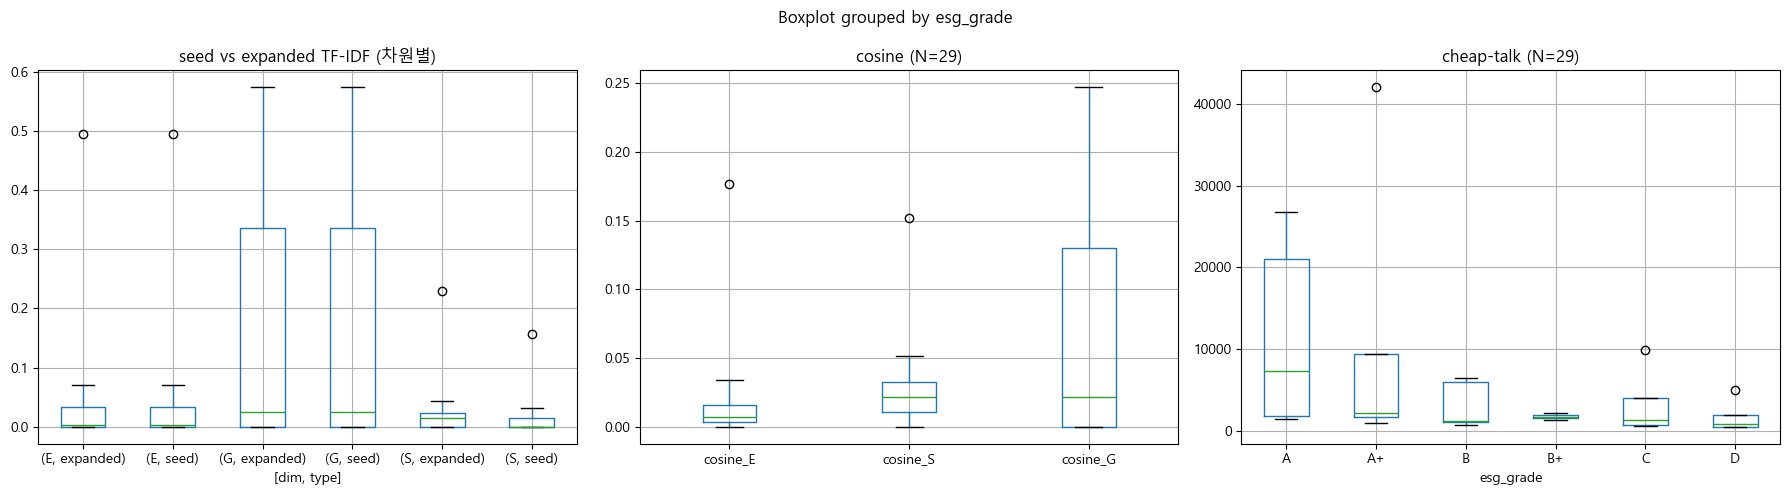


🎯 다음: 03_mining v_final (29 firm-year — Spearman·OLS·ordered·binary 모두 가능)


In [7]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# (1) seed vs expanded TF-IDF 분포
if N >= 5:
    melt_s = features[['seed_tfidf_E','seed_tfidf_S','seed_tfidf_G']].melt(var_name='dim', value_name='score')
    melt_s['type'] = 'seed'
    melt_e = features[['expanded_tfidf_E','expanded_tfidf_S','expanded_tfidf_G']].melt(var_name='dim', value_name='score')
    melt_e['type'] = 'expanded'
    melt = pd.concat([melt_s, melt_e])
    melt['dim'] = melt['dim'].str.split('_').str[-1]
    melt.boxplot(column='score', by=['dim','type'], ax=axes[0])
    axes[0].set_title('seed vs expanded TF-IDF (차원별)')
else:
    axes[0].bar(['E','S','G'], features[['seed_tfidf_E','seed_tfidf_S','seed_tfidf_G']].iloc[0].values, color=['#10b981','#f59e0b','#8b5cf6'])
    axes[0].set_title(f'seed TF-IDF (N={N})')

# (2) cosine
if N >= 5:
    features[['cosine_E','cosine_S','cosine_G']].boxplot(ax=axes[1])
else:
    axes[1].bar(['E','S','G'], features[['cosine_E','cosine_S','cosine_G']].iloc[0].values, color=['#06b6d4','#ec4899','#84cc16'])
axes[1].set_title(f'cosine (N={N})')

# (3) word_count vs grade
if N >= 5:
    features.boxplot(column='word_count', by='esg_grade', ax=axes[2])
else:
    axes[2].bar(['word_count','specificity*100'], [features['word_count'].iloc[0], features['specificity_score'].iloc[0]*100])
axes[2].set_title(f'cheap-talk (N={N})')

plt.tight_layout()
plt.savefig(ROOT/'data'/'processed'/'fig_v_final_preprocess.png', dpi=120)
plt.show()

print(f'\n🎯 다음: 03_mining v_final ({N} firm-year — Spearman·OLS·ordered·binary 모두 가능)')
